# Single star

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares

The ``GaiaAstrometry`` class is used for storing Gaia epoch astrometry. For now, we can simulate epoch astrometry for Gaia DR4 or DR5. To do so, we can either set the stellar parameters manually or retrieve parameters from DR3. In this example, we will simulate DR4 epoch astrometry for the star [HD 135344 A](https://en.wikipedia.org/wiki/HD_135344).

In [3]:
source_id = 6199395656645840384  # HD 135344 A
primary_mass = (2.2, 0.1)  # (Msun)

In [4]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release='DR4')


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 2.20 +/- 0.10


Next, we query the stellar parameters from Gaia DR3. These will be stored as attributes of the `GaiaAstrometry` object and returned as list for convenience.

In [5]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6199395656645840384


RA = 228.954 deg +/- 0.038 mas
Dec = -37.149 deg +/- 0.026 mas
Parallax = 7.411 +/- 0.040 mas
Proper motion in RA = -18.738 +/- 0.051 mas/yr
Proper motion in Dec = -24.008 +/- 0.035 mas/yr
G-band magnitude = 7.748
Pseudocolor = 1.73 um-1

UWE = 1.96
RUWE = 0.95
Astrometric excess noise (mas) = 0.2075 +/- 0.0103
Non single star = 0


In [6]:
print(star_param)

{'ra_ref': 228.9538383003218, 'dec_ref': -37.14892097020482, 'parallax': 7.410549860402929, 'pm_ra': -18.737737844165032, 'pm_dec': -24.00776147540073, 'g_mag': 7.748194217681885}


We use the retrieved parameters of HD 135344 A, so we don't need to provide any parameters in the ``model_param`` dictionary.

In [7]:
model_param = epoch_astrom.simulate_data(
    model_param=None,
    mass_2=None,
    flux_ratio=None,
    occ_rate=None,
    sigma_per_ccd=None,
    csv_out=None,
    seed=1,
    reject_fraction=False,
)


-------------
Simulate data
-------------

System type: single

Primary mass (Msun): 2.20 +/- 0.10

AL scan uncertainty (per CCD) = 193.14 uas
AL scan uncertainty (per transit) = 68.29 uas

Star model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 7.411
   - Proper motion in RA (mas/yr) = -18.738
   - Proper motion in Dec (mas/yr) = -24.008


In [8]:
print(model_param)

{'parallax': 7.410549860402929, 'pm_ra': -18.737737844165032, 'pm_dec': -24.00776147540073, 'ra_offset': 0.0, 'dec_offset': 0.0}


Next, we run a 5-parameter least-squares fit to determine the best-fit parameters and uncertainties of the stellar track.

In [9]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 0.946
RUWE = 0.973
F2 estimator = -0.321
Inflation factor = 0.976

Best-fit parameters:
   - RA offset = -0.012 +/- 0.014 mas
   - Dec offset = -0.007 +/- 0.010 mas
   - Parallax = 7.410 +/- 0.016 mas
   - mu in RA = -18.737 +/- 0.009 mas/yr
   - mu in Dec = -24.006 +/- 0.005 mas/yr


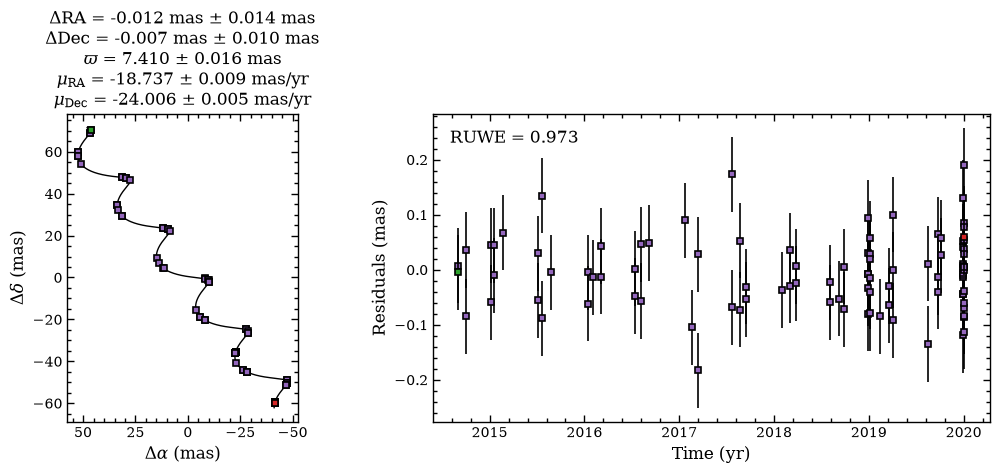

In [10]:
results = leastsq.singl_5param(plot_file='plot.png')

Indeed we infer a proper motion and parallax that is consistent with the numbers in Gaia DR3.